## Feature scaling

- **Feature scaling** refers to the methods or techniques used to normalize the range of independent variables in our data, or in other words, the methods to set the feature value range within a similar scale.

- Variables with bigger magnitude / larger value range dominate over those with smaller magnitude / value range.

- Scale of the features is an important consideration when building machine learning models.
- Feature scaling is generally the last step in the data preprocessing pipeline, performed **just before training the machine learning algorithms**.

### Feature Scaling importance in some ML Algorithms like

- Linear and Logistic Regression
    - The Regression coefficients of linear models are directly influenced by the scale of the variable.

- Gradient descent converges faster when features are on similar scales

- Support Vector Machines
    - Feature scaling helps decrease the time to find support vectors for SVMs

- K-mean clusturing
    - Euclidean distances are sensitive to feature magnitude.

- Principle Component Analysis (PCA)
    - PCA require the features to be centered at 0.

### Various Feature Scaling Techniques

There are several Feature Scaling techniques, which we will discuss throughout this section:

  - Standardisation
  - Normalisation

       - Scaling to minimum and maximum values - MinMaxScaling
       - Scaling to maximum value - MaxAbsScaling
       - Scaling to quantiles and median - RobustScaling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('titanic.csv', usecols=['Age'])
df.head()

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [3]:
df.isnull().sum()

Age    177
dtype: int64

In [4]:
df.Age.fillna(df.Age.median(), inplace=True)


C:\Users\abhay\AppData\Local\Temp\ipykernel_37396\3442022827.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df.Age.median(), inplace=True)


In [5]:
df.isnull().sum()

Age    0
dtype: int64

## Standardisation

Stadardisation involves centering the variable at zero, and standardising the variance to 1.

**z = (x - x_mean)/std**

The result of the above transformation is **z**, which is called the z-score, and represents how many standard deviations a given observation deviates from the mean. A z-score specifies the location of the ovservation within a distribution (in numbers of standard deviations respect to the mean of the distribution). The sign of the z-score (+ or -) indicates whether the observation is above (+) or below (-) the mean.

The shape of standardised (or z-scored normalised) distribution will be identical to the original distribution of the variable. if the original distribution is normal, then the standardised distribution will be normal. But, if the original distribution is skewed, then the standardised distributioin of the variable will also be skewed.

standardisation:

 - centers the meant at 0
 - scales the variance at 1
 - preserves the shape of the original distribution
 - the minimum and maximum values of the different variables may vary
 - preserves outliers

In [9]:
### Standardisation: We use the Standardscaler from sklearn library

from sklearn.preprocessing import StandardScaler

## call the function

sc = StandardScaler()


### fit_transform

df['Age_sc'] = sc.fit_transform(df[['Age']])

In [10]:
df

,Age,Age_sc
0,22.0,-0.565736
1,38.0,0.663861
2,26.0,-0.258337
3,35.0,0.433312
4,35.0,0.433312
...,...,...
886,27.0,-0.181487
887,19.0,-0.796286
888,28.0,-0.104637
889,26.0,-0.258337


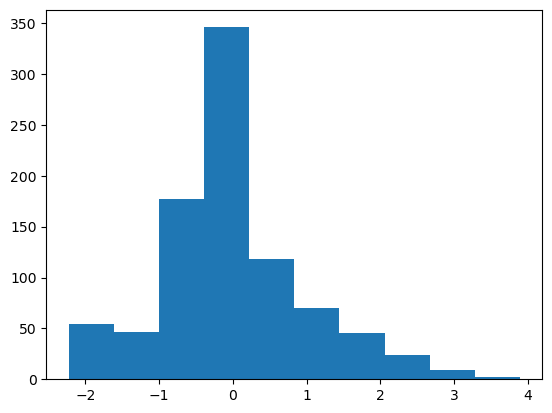

In [11]:
plt.hist(df.Age_sc)
plt.show()

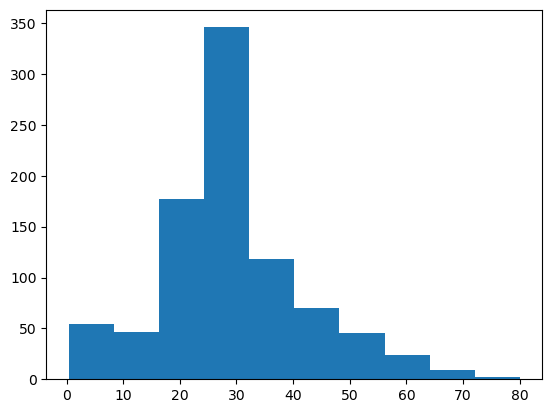

In [12]:
plt.hist(df.Age)
plt.show()

## Min Max Scaling (CNN - Deep Learning Techniques)

Min Max Scaling scales the values between 0 to 1. X_scaled = (X - X.min/(X.max - X.min))

In [15]:
### Normalization: We use the MinMaxScaler from sklearn library

from sklearn.preprocessing import MinMaxScaler

## call the function

min_max = MinMaxScaler()

### fit_transform

df['Age_mn'] = min_max.fit_transform(df[['Age']])

In [16]:
df

,Age,Age_sc,Age_mn
0,22.0,-0.565736,0.271174
1,38.0,0.663861,0.472229
2,26.0,-0.258337,0.321438
3,35.0,0.433312,0.434531
4,35.0,0.433312,0.434531
...,...,...,...
886,27.0,-0.181487,0.334004
887,19.0,-0.796286,0.233476
888,28.0,-0.104637,0.346569
889,26.0,-0.258337,0.321438


#### Robust Scaler

It it used to scale the feature to median and quantiles Scaling using median and quantiles consists of substracting the median to all the observations, and then dividing by the interquantile difference.
The interquantile difference is the difference between the 75th and 25th quanliite:

IOR =75th quantile - 25th quantile

X_scaled = (X - X.median) / IOR

0,1,2,3,4,5,6,7,8,9,10

9 -99 percentile --- 90% of all values in this gruop is less than 9, 1-10 prencentile --- 10% of all values in this group is less than 1 , 44-%

In [17]:
## normalization: We use the RobustScaler from sklearn library

from sklearn.preprocessing import RobustScaler

## call the function

rs = RobustScaler()

## fit_transform

df['Age_rs'] = rs.fit_transform(df[['Age']])
df

,Age,Age_sc,Age_mn,Age_rs
0,22.0,-0.565736,0.271174,-0.461538
1,38.0,0.663861,0.472229,0.769231
2,26.0,-0.258337,0.321438,-0.153846
3,35.0,0.433312,0.434531,0.538462
4,35.0,0.433312,0.434531,0.538462
...,...,...,...,...
886,27.0,-0.181487,0.334004,-0.076923
887,19.0,-0.796286,0.233476,-0.692308
888,28.0,-0.104637,0.346569,0.000000
889,26.0,-0.258337,0.321438,-0.153846


### MaxAbsScaling

- The MaxAbsScaler fro sklearn rescales features to their maximum values, so that the new maximum values is 1.

- When performing maximum absolute scaling on the data set, wen need to first identify the maximum values of the variables.


               X_scaled = X / Xmax

In [18]:
### Normalization: We use the MaxAbsScaller from sklearn library

from sklearn.preprocessing import MaxAbsScaler

mas = MaxAbsScaler()

df['Age_mas'] = mas.fit_transform(df[['Age']])
df

,Age,Age_sc,Age_mn,Age_rs,Age_mas
0,22.0,-0.565736,0.271174,-0.461538,0.2750
1,38.0,0.663861,0.472229,0.769231,0.4750
2,26.0,-0.258337,0.321438,-0.153846,0.3250
3,35.0,0.433312,0.434531,0.538462,0.4375
4,35.0,0.433312,0.434531,0.538462,0.4375
...,...,...,...,...,...
886,27.0,-0.181487,0.334004,-0.076923,0.3375
887,19.0,-0.796286,0.233476,-0.692308,0.2375
888,28.0,-0.104637,0.346569,0.000000,0.3500
889,26.0,-0.258337,0.321438,-0.153846,0.3250
